# Hierarchical Clustering (Clustering Jerárquico Aglomerativo)

## ¿Qué es?

Construye una jerarquía de clusters mediante un proceso **bottom-up** (aglomerativo):
1. Cada punto empieza siendo su propio cluster
2. En cada paso, los dos clusters más "cercanos" se fusionan
3. Se repite hasta que quede un solo cluster

El resultado se visualiza con un **dendrograma**.

## Criterios de enlace (Linkage):
- **ward**: minimiza la varianza dentro de los clusters (más usado)
- **complete**: distancia máxima entre puntos de dos clusters
- **average**: distancia promedio entre puntos de dos clusters
- **single**: distancia mínima (puede generar clusters largos "cadenas")


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

%matplotlib inline


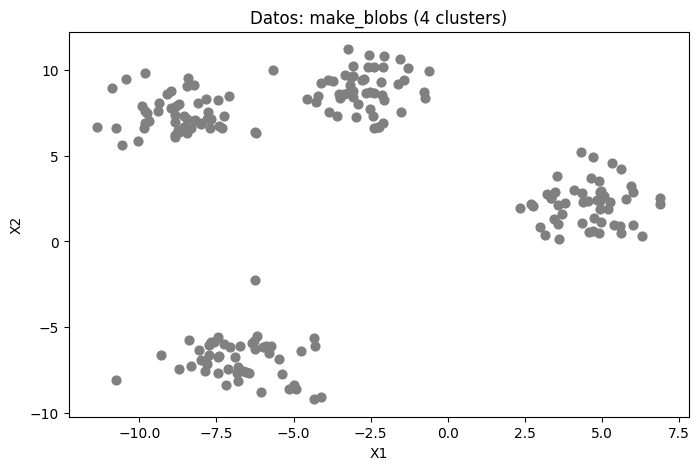

In [2]:
X, y_true = make_blobs(n_samples=200, centers=4, cluster_std=1.2, random_state=42)

plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c='gray', s=40)
plt.title('Datos: make_blobs (4 clusters)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()


## Paso 1: Graficar el dendrograma

El dendrograma nos ayuda a decidir cuántos clusters elegir.


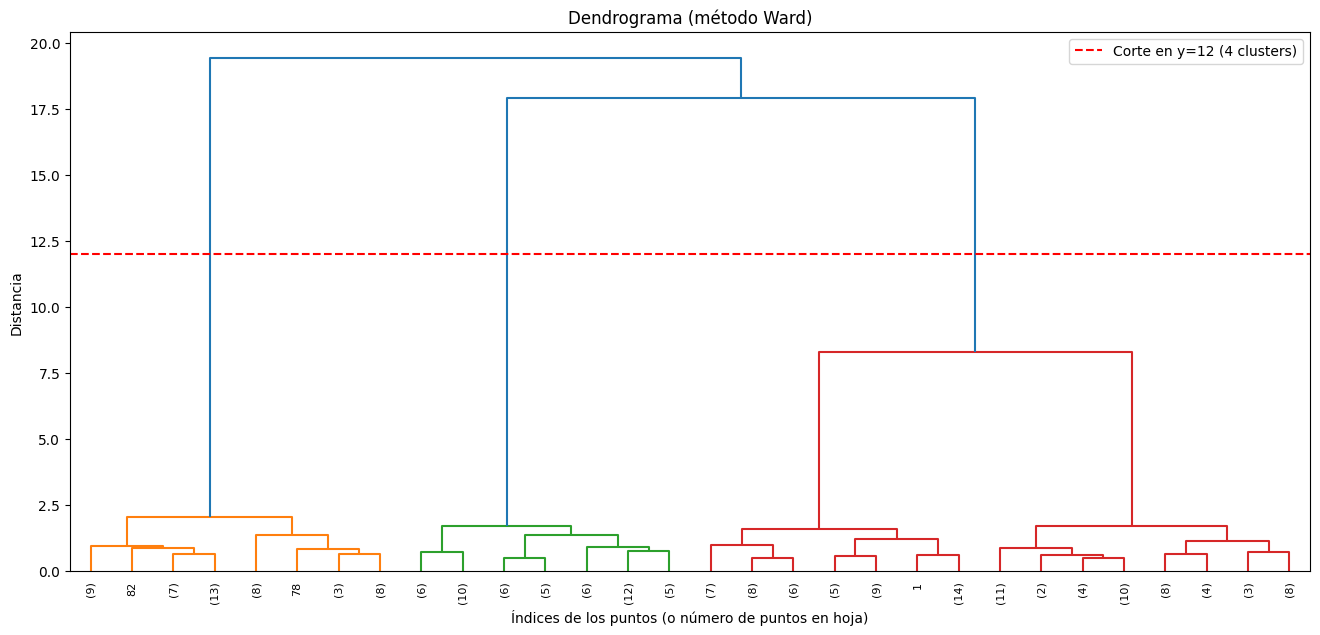

In [3]:
X_scaled = StandardScaler().fit_transform(X)

Z = linkage(X_scaled, method='ward', metric='euclidean')

plt.figure(figsize=(16, 7))
dendrogram(Z, leaf_rotation=90, leaf_font_size=8, truncate_mode='lastp', p=30)
plt.title('Dendrograma (método Ward)')
plt.xlabel('Índices de los puntos (o número de puntos en hoja)')
plt.ylabel('Distancia')
plt.axhline(y=12, color='r', linestyle='--', label='Corte en y=12 (4 clusters)')
plt.legend()
plt.show()


## Paso 2: Aplicar AgglomerativeClustering


In [4]:
agg = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
labels = agg.fit_predict(X_scaled)

print('Etiquetas únicas:', np.unique(labels))
print('Tamaño de cada cluster:', np.bincount(labels))


Etiquetas únicas: [0 1 2 3]
Tamaño de cada cluster: [50 50 50 50]


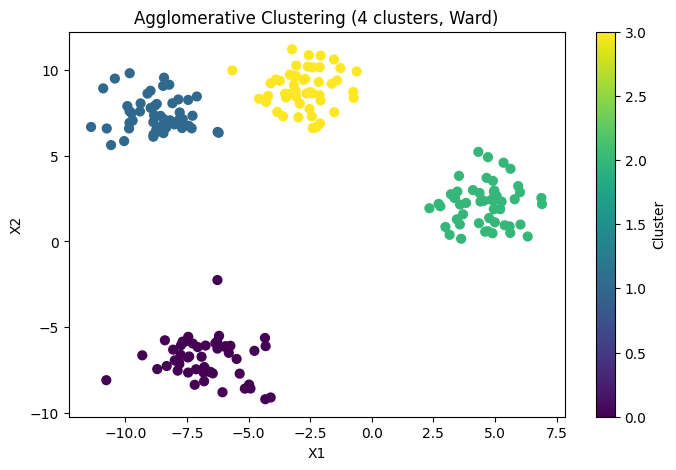

In [5]:
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=40)
plt.title('Agglomerative Clustering (4 clusters, Ward)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.colorbar(label='Cluster')
plt.show()


## Paso 3: Comparar métodos de enlace


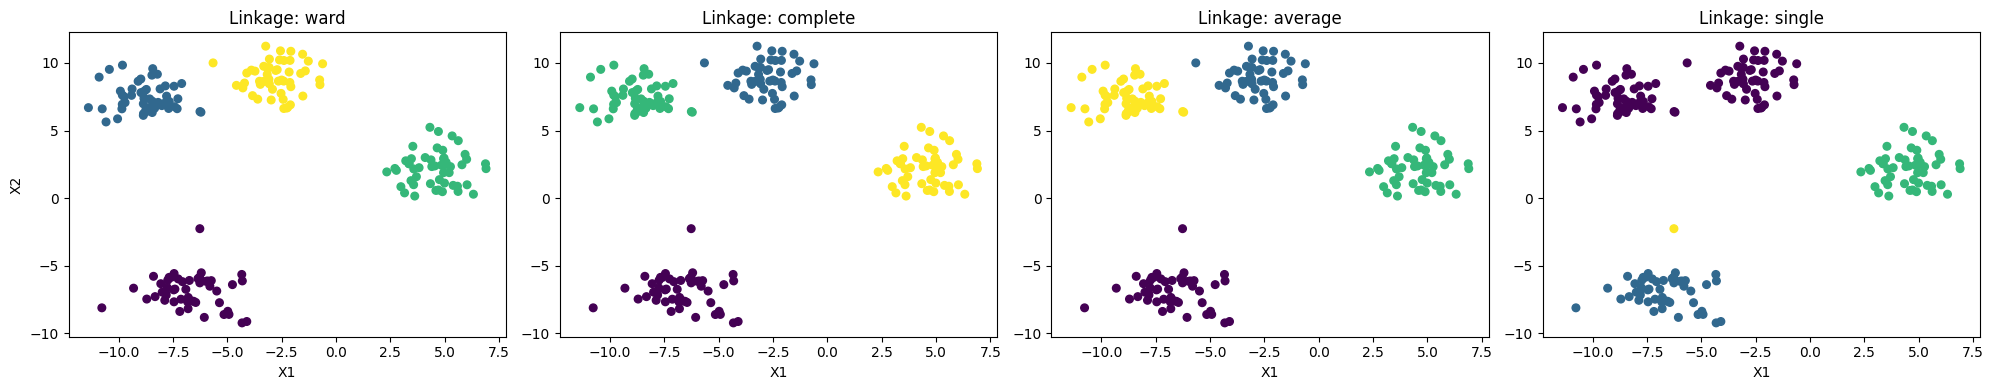

In [6]:
linkages = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for i, link in enumerate(linkages):
    agg = AgglomerativeClustering(n_clusters=4, linkage=link, metric='euclidean' if link != 'ward' else 'euclidean')
    lbls = agg.fit_predict(X_scaled)
    axes[i].scatter(X[:, 0], X[:, 1], c=lbls, cmap='viridis', s=30)
    axes[i].set_title(f'Linkage: {link}')
    axes[i].set_xlabel('X1')
axes[0].set_ylabel('X2')
plt.tight_layout()
plt.show()


## Resumen

| Ventaja | Desventaja |
|---|---|
Interpretación visual vía dendrograma | O(n³) en el peor caso |
No necesita K *a priori* (pero lo necesitas al final) | No puedes reajustar después de fusionar |
Fácil de entender | Menos eficiente en datos grandes |
